.\env\Scripts\activate

In [1]:
#---------------------------------------------------
# IMPORTS
#---------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.io import wavfile
import soundfile as sf

In [7]:
def generar_barrido_logaritmico(duracion=10.0, fs=44100, f0=20.0, f1=20000.0):
    """
    Genera un barrido de tonos (sine sweep) logarítmico de 20Hz a 20kHz.
    
    Parámetros:
        duracion: Segundos que dura el barrido.
        fs: Frecuencia de muestreo.
        f0: Frecuencia inicial (Hz).
        f1: Frecuencia final (Hz).
    """
    # Creamos el vector de tiempo
    t = np.linspace(0, duracion, int(fs * duracion), endpoint=False)
    
    # Usamos la función chirp de scipy para el barrido logarítmico
    sweep = signal.chirp(t, f0=f0, f1=f1, t1=duracion, method='logarithmic')
    
    # ¡TRUCO PRO! Aplicar un fundido de entrada/salida (Tukey window)
    # Esto evita "clicks" bruscos al inicio y al final de la onda que estropearían la FFT
    ventana = signal.windows.tukey(len(sweep), alpha=0.01)
    sweep_limpio = sweep * ventana

    wavfile.write("barrido_logaritmico.wav", fs, sweep_limpio.astype(np.float32))  # Guardamos el barrido para futuras pruebas

hola= generar_barrido_logaritmico(duracion=10.0, fs=44100, f0=20.0, f1=20000.0)


In [2]:
#---------------------------------------------------
# FUNCIONES
#---------------------------------------------------

def generador_ruido_rosa(longitud):
    """
    Genera ruido rosa aplicando un filtro de 1/sqrt(f) a ruido blanco puro
    en el dominio de la frecuencia.
    """
    # Genera ruido blanco
    ruido_blanco = np.random.randn(longitud)
    
    # Paso al dominio de la frecuencia (FFT real)
    X = np.fft.rfft(ruido_blanco)
    
    # Vector de frecuencias
    frecuencias = np.fft.rfftfreq(longitud)
    frecuencias[0] = 1.0  # Evita la división por cero en la componente continua (DC)
    
    # Aplica el filtro: la amplitud cae proporcionalmente a 1/sqrt(f)
    X_rosa = X / np.sqrt(frecuencias)
    
    # Vuelta al dominio del tiempo
    ruido_rosa = np.fft.irfft(X_rosa, n=longitud)
    
    # Normalizacion por pico absoluto (como con la referencia)
    pico_ruido = np.max(np.abs(ruido_rosa))
    if pico_ruido > 0:
        ruido_rosa = ruido_rosa / pico_ruido
        
    return ruido_rosa

def wav_to_code(ruta_archivo):
    """
    Lee CUALQUIER archivo de audio (16, 24, 32 bits, float) usando 'soundfile'.
    Lo devuelve siempre normalizado entre -1.0 y 1.0 en formato float32.
    Lo convierte a Mono si es estéreo. 

    Parámetros:
        ruta_archivo: Ruta del archivo de audio a leer.

    Retorna:
        sample_rate: Frecuencia de muestreo del archivo.
        data: Array NumPy con la señal normalizada a 32 bits.
    """
    # Soundfile lee el audio y ya lo entrega normalizado en flotante
    data, sample_rate = sf.read(ruta_archivo)
    
    # Comprobacion de si es stereo (soundfile devuelve [muestras, canales])
    if len(data.shape) > 1 and data.shape[1] > 1:
        # Suma L y R y divides para hacer mono
        data = np.mean(data, axis=1)
        
    # Paso a float32 para que ocupe la mitad de memoria RAM que el float64
    return sample_rate, data.astype(np.float32)

def funcion_transferencia(ref_signal, mic_signal, sample_rate, ventana_fft=4096):
    """
    Calcula la Función de Transferencia H(f) y la Coherencia entre una señal 
    de referencia (mesa) y una de medición (micrófono).
    
    Parámetros:
        ref_signal: Array NumPy con el audio de la mesa (FOH). (señal normalizada)
        mic_signal: Array NumPy con el audio del micrófono de medición. (señal normalizada)
        sample_rate: Frecuencia de muestreo.
        ventana_fft: Tamaño de la ventana (frame) para el promediado de Welch.
    
    Retorna:
        frecuencias: Array frecuencias en Hz. (eje x)
        magnitud_db: Array diferencia de EQ en dB. (eje y)
        fase_grados: Array con la diferencia de fase en Grados.
        coherencia:  Array con la causalidad (valores de 0.0 a 1.0).
    """
    
    # Comprobacion de que sean del mismo tamaño
    min_length = min(len(ref_signal), len(mic_signal))
    ref_recortada = ref_signal[:min_length]
    mic_recortada = mic_signal[:min_length]
    
    # Espectro de Potencia de la Referencia (Pxx)
    frecuencias, Pxx_ref = signal.welch(ref_recortada, fs=sample_rate, nperseg=ventana_fft)
    
    # Espectro Cruzado (Pxy) - Lo que tienen en común
    _, Pxy = signal.csd(ref_recortada, mic_recortada, fs=sample_rate, nperseg=ventana_fft)
    
    # Función de Transferencia H_f
    H_f = Pxy / (Pxx_ref + 1e-12) # Evita división por cero con un pequeño valor añadido
    
    # Magnitud (EQ) pasado a dB
    magnitud_db = 20 * np.log10(np.abs(H_f) + 1e-12)
    
    # Fase (Retardo) pasado a grados
    fase_grados = np.angle(H_f, deg=True)
    
    # Calculo de la Coherencia
    _, coherencia = signal.coherence(ref_recortada, mic_recortada, fs=sample_rate, nperseg=ventana_fft)
    
    return frecuencias, magnitud_db, fase_grados, coherencia

def to_1_3_oct(frecuencias, magnitud_db, fase_grados, coherencia):
    """
    Agrupa los datos lineales de una FFT de alta resolución en las 31 bandas 
    estándar de 1/3 de octava (ISO 266).

    Parámetros: (iguales a la SALIDA de funcion_transferencia)
        frecuencias: Array frecuencias en Hz. (eje x)
        magnitud_db: Array diferencia de EQ en dB. (eje y)
        fase_grados: Array con la diferencia de fase en Grados.
        coherencia:  Array con la causalidad (valores de 0.0 a 1.0).
    
    Retorna:
        fc: frecuencias centrales de los tercios de octava.
        mag_1_3: magnitud de los tercios de octava.
        fase_1_3: fase de los tercios de octava.
        coh_1_3: coherencia de los tercios de octava.
    """
    
    # Frecuencias centrales ISO 266
    fc = np.array([20, 25, 31.5, 40, 50, 63, 80, 100, 125, 160, 200, 250, 315, 
                   400, 500, 630, 800, 1000, 1250, 1600, 2000, 2500, 3150, 
                   4000, 5000, 6300, 8000, 10000, 12500, 16000, 20000])

    mag_1_3 = []
    fase_1_3 = []
    coh_1_3 = []

    # Conversion dB a lineal para promediar la energía acústica correctamente
    mag_lineal = 10 ** (magnitud_db / 20)

    # Desenvolver la fase (unwrap) evita que el promedio falle cuando la fase salta bruscamente de +180 a -180
    fase_unwrapped = np.unwrap(np.deg2rad(fase_grados))

    # Agrupacion datos ("Bins" de la FFT) en cada banda
    for f in fc:
        f_min = f / (2 ** (1/6))
        f_max = f * (2 ** (1/6))

        # Encontrar los índices de las frecuencias que caen dentro de esta banda
        indices = np.where((frecuencias >= f_min) & (frecuencias < f_max))[0]

        if len(indices) > 0:
            # Promediado de magnitud y paso a dB
            mag_promedio_lin = np.mean(mag_lineal[indices])
            mag_1_3.append(20 * np.log10(mag_promedio_lin))
            
            # Promediado de fase y paso a grados
            fase_promedio_rad = np.mean(fase_unwrapped[indices])
            fase_1_3.append(np.rad2deg(fase_promedio_rad))
            
            # Promediado de coherencia
            coh_1_3.append(np.mean(coherencia[indices]))
        else:
            # Buscamos el punto de la FFT de alta resolución más cercano a f
            idx_cercano = np.argmin(np.abs(frecuencias - f))
            
            # En lugar de 0, usamos los datos reales de ese punto exacto
            mag_1_3.append(magnitud_db[idx_cercano])
            fase_1_3.append(fase_grados[idx_cercano])
            coh_1_3.append(coherencia[idx_cercano])

    # Volver a envolver la fase entre -180 y +180 grados
    fase_1_3 = (np.array(fase_1_3) + 180) % 360 - 180

    return fc, np.array(mag_1_3), np.array(fase_1_3), np.array(coh_1_3)

def algoritmo_correccion_eq(mag_medida, coh_medida, mag_objetivo=None, umbral_coh=0.7, max_cut=-12.0, max_boost=6.0):
    """
    Calcula los valores de ecualización (en dB) necesarios para que la 
    señal medida alcance la curva objetivo, utilizando la coherencia 
    como filtro de seguridad.

    Parámetros:
        mag_medida: Array de 31 valores (magnitud en dB de la sección medida).
        coh_medida: Array de 31 valores (coherencia de la medición).
        mag_objetivo: Array de 31 valores con la EQ ideal (Ej: el FOH). 
                      Si es None, se asume un objetivo de 0 dB (respuesta plana).
        umbral_coh: Valor mínimo de coherencia (0.0 a 1.0) para aplicar corrección.
        max_cut: Límite máximo de atenuación en dB (seguridad).
        max_boost: Límite máximo de realce en dB (seguridad para los amplificadores).

    Retorna:
        correccion_final: Array de 31 valores con los dB a aplicar en el ecualizador gráfico.
    """
    
    # Definicion del objetivo (Si no se le pasa uno, asume 0 dB para todas las bandas)
    if mag_objetivo is None:
        mag_objetivo = np.zeros_like(mag_medida)
        
    # Calculo diferencia
    diferencia_bruta = mag_objetivo - mag_medida
    
    # Límites de Seguridad (Clamping)
    correccion_limitada = np.clip(diferencia_bruta, max_cut, max_boost)
    
    # Correccion en banda con coherencia suficiente, 0 dB en bandas con baja coherencia
    correccion_final = np.where(coh_medida >= umbral_coh, correccion_limitada, 0.0)
    
    return correccion_final

def simulador_audio_sala(audio_referencia, sample_rate, eq_curva_db, filename, nivel_ruido=0.0, tipo_ruido="rosa", archivo_ruido=None):
    """
    Genera un archivo de audio en base a una referencia, simulando lo que captaría un micrófono de medición.
    Aplica una curva de EQ de 31 bandas e inyecta ruido para 
    poner a prueba el cálculo de coherencia.

    Parámetros:
        audio_referencia: Array NumPy con el audio de la mesa (FOH).
        sample_rate: Frecuencia de muestreo.
        eq_curva_db: Array o lista de 31 valores (dB) simulando la respuesta de la sala.
        filename: Nombre del archivo de salida.
        nivel_ruido: Cantidad de ruido del público (0.0 a 1.0). Destruye la coherencia.
        tipo_ruido: "rosa" para ruido rosa generado, "publico" para ruido de archivo.
        archivo_ruido: Ruta del archivo de audio a usar como ruido (si tipo_ruido es "publico").
    """
    fc = np.array([20, 25, 31.5, 40, 50, 63, 80, 100, 125, 160, 200, 250, 315, 
                   400, 500, 630, 800, 1000, 1250, 1600, 2000, 2500, 3150, 
                   4000, 5000, 6300, 8000, 10000, 12500, 16000, 20000])
    
    # Diseño del filtro de la sala
    ganancia_lineal = 10 ** (np.array(eq_curva_db) / 20.0)
    freqs_fir = np.concatenate(([0.0], fc, [sample_rate / 2.0]))
    gains_fir = np.concatenate(([ganancia_lineal[0]], ganancia_lineal, [ganancia_lineal[-1]]))
    filtro_fir = signal.firwin2(4097, freqs_fir, gains_fir, fs=sample_rate)
    
    # Pasa el MISMO audio de la mesa por la sala
    audio_filtrado = signal.fftconvolve(audio_referencia, filtro_fir, mode='same')

    # Iguala el volumen a la referencia ANTES del ruido
    # pico = np.max(np.abs(audio_filtrado))
    # if pico > 0:
    #     audio_filtrado = audio_filtrado / pico
    
    # Inyeccion de ruido
    if nivel_ruido > 0:
        longitud_necesaria = len(audio_referencia)
        
        if tipo_ruido == "rosa":
            ruido_base = generador_ruido_rosa(longitud_necesaria)
            
        elif tipo_ruido == "publico" and archivo_ruido is not None:
            # Llamada interna al lector de WAVs
            fs_ruido, ruido_base = wav_to_code(archivo_ruido)
            
            # Comprobacion de sample rate para evitar errores de alineación temporal
            if fs_ruido != sample_rate:
                print(f"⚠️ Aviso en {filename}: El sample rate del ruido ({fs_ruido}Hz) no coincide con la música ({sample_rate}Hz).")
            
            # Ajuste explícito de duraciones
            if len(ruido_base) > longitud_necesaria:
                # Si el ruido es MÁS LARGO, se corta al tamaño necesario
                ruido_base = ruido_base[:longitud_necesaria]
                
            elif len(ruido_base) < longitud_necesaria:
                # Si el ruido es MÁS CORTO, se repite en bucle hasta alcanzar la longitud necesaria
                repeticiones = int(np.ceil(longitud_necesaria / len(ruido_base)))
                ruido_base = np.tile(ruido_base, repeticiones)[:longitud_necesaria]
                
            # 4. Normalizamos el ruido por su pico absoluto
            pico_ruido = np.max(np.abs(ruido_base))
            if pico_ruido > 0:
                ruido_base = ruido_base / pico_ruido
        else:
            ruido_base = np.zeros(longitud_necesaria) 

        # Multiplicamos por el fader de nivel y lo sumamos a la sala
        audio_filtrado += ruido_base * nivel_ruido
        
    # Guardamos en float32
    wavfile.write(filename, sample_rate, audio_filtrado.astype(np.float32))

In [ ]:
#---------------------------------------------------
# PROCESADO DE AUDIO
#---------------------------------------------------

# Parametros
reference_file = "referencia_radiohead.wav"
umbral_coherencia = 0.7
max_cut = -12.0
max_boost = 10.0

# Frecuencias:             20Hz, 25Hz, 31.5Hz, 40Hz, 50Hz, 63Hz, 80Hz, 100Hz, 125Hz, 160Hz, 200Hz, 250Hz, 315Hz, 400Hz, 500Hz, 630Hz, 800Hz, 1000Hz, 1250Hz, 1600Hz, 2000Hz, 2500Hz, 3150Hz, 4000Hz, 5000Hz, 6300Hz, 8000Hz, 10000Hz, 12500Hz, 16000Hz, 20000Hz
curva_objetivo = np.array([ 0.0,  0.0,    6.0,  6.0,  6.0,  6.0,  6.0,   6.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,     0.0,     0.0,     0.0,    0.0])
eq_micro_foh = np.array(  [ 0.0,  0.0,    0.0,  0.0,  0.0,  0.0,  0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,     0.0,     0.0,     0.0,    0.0])
eq_micro_sec1 = np.array( [ 0.0,  0.0,    -3.0,  -3.0,  -3.0,  -3.0,  -3.0,   -3.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,   0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,    0.0,     0.0,     0.0,     0.0,    0.0])

# referencia FOH
fs, referencia = wav_to_code(reference_file)

eq_referencia_FOH = curva_objetivo.copy()
simulador_audio_sala(referencia, fs, eq_referencia_FOH, "V1_referencia_EQ.wav", nivel_ruido=0.0, tipo_ruido="publico", archivo_ruido="ruido_publico.wav")

# Micro FOH 
simulador_audio_sala(referencia, fs, eq_micro_foh, "V1_micro_FOH.wav", nivel_ruido=0.0, tipo_ruido="publico", archivo_ruido="ruido_publico.wav")

# Micro 1
simulador_audio_sala(referencia, fs, eq_micro_sec1, "V1_micro_medicion1.wav", nivel_ruido=0.6, tipo_ruido="publico", archivo_ruido="ruido_publico.wav")

mix_out_FOH = wav_to_code("V1_referencia_EQ.wav")
micro_FOH = wav_to_code("V1_micro_FOH.wav")
micro1 = wav_to_code("V1_micro_medicion1.wav")

FT_FOH = funcion_transferencia(mix_out_FOH[1], micro_FOH[1], fs)
FT_micro1 = funcion_transferencia(mix_out_FOH[1], micro1[1], fs)

FT_FOH_1_3 = to_1_3_oct(*FT_FOH)
FT_micro1_1_3 = to_1_3_oct(*FT_micro1)

correccion = algoritmo_correccion_eq(FT_micro1_1_3[1], FT_micro1_1_3[3], mag_objetivo=FT_FOH_1_3[1], umbral_coh=umbral_coherencia, max_cut=max_cut, max_boost=max_boost)


# # Vamos a coger solo 2 segundos de audio (del segundo 1 al 3) para que la gráfica no colapse
# inicio = fs * 1
# fin = fs * 3

# plt.figure(figsize=(12, 6))

# # 1. Gráfica de la señal original limpia
# ax1 = plt.subplot(2, 1, 1)
# ax1.plot(mix_out_FOH[1][inicio:fin], color='blue', linewidth=0.5)
# ax1.set_title("1. Señal FOH (Referencia limpia)")
# ax1.set_ylim([-1.1, 1.1])
# ax1.grid(True)

# # 2. Gráfica de la señal con ruido
# ax2 = plt.subplot(2, 1, 2)
# ax2.plot(micro1[1][inicio:fin], color='red', linewidth=0.5)
# ax2.set_title(f"2. Señal Micro 1 (Debería ser un bloque difuso de ruido si nivel_ruido=0.5)")
# ax2.set_ylim([-1.1, 1.1])
# ax2.grid(True)

# plt.tight_layout()
# plt.show()

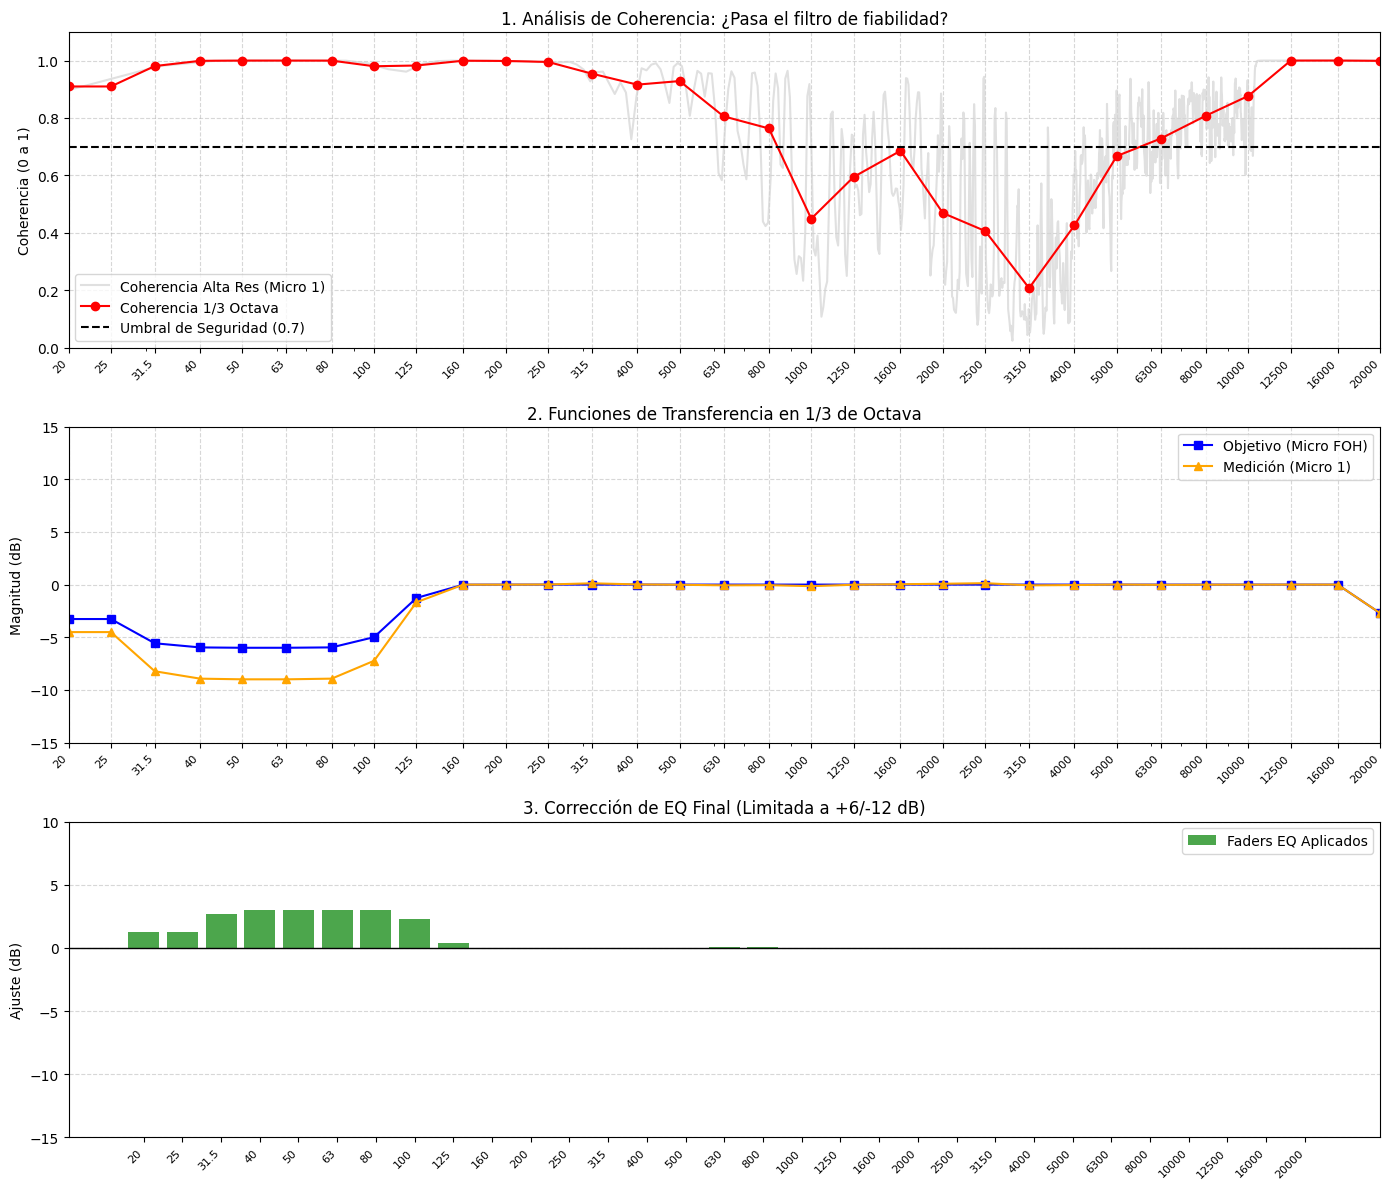

Valores de corrección generados por el algoritmo:
[ 1.24  1.24  2.66  2.97  3.    3.    2.97  2.24  0.41 -0.    0.   -0.01
 -0.12 -0.02  0.02  0.07  0.05  0.    0.    0.    0.    0.    0.    0.
  0.    0.02  0.01  0.   -0.    0.    0.  ]


In [4]:
# Extraemos las frecuencias centrales para el eje X
fc = FT_FOH_1_3[0]
etiquetas_x = [str(int(f)) if f == int(f) else str(f) for f in fc]

# Creamos un lienzo grande para las 3 gráficas
plt.figure(figsize=(14, 12))

# --- Gráfica 1: COHERENCIA (El semáforo) ---
# Aquí veremos si el ruido del 0.4 ha destruido la fiabilidad de la medición
ax1 = plt.subplot(3, 1, 1)
# Pintamos la coherencia cruda (gris) y la promediada en tercios (rojo)
ax1.semilogx(FT_micro1[0], FT_micro1[3], label='Coherencia Alta Res (Micro 1)', color='lightgray', alpha=0.7)
ax1.semilogx(fc, FT_micro1_1_3[3], marker='o', label='Coherencia 1/3 Octava', color='red')
ax1.axhline(0.7, color='black', linestyle='--', label='Umbral de Seguridad (0.7)')
ax1.set_title('1. Análisis de Coherencia: ¿Pasa el filtro de fiabilidad?')
ax1.set_ylabel('Coherencia (0 a 1)')
ax1.set_ylim([0, 1.1])
ax1.set_xlim([20, 20000])
ax1.set_xticks(fc)
ax1.set_xticklabels(etiquetas_x, rotation=45, ha='right', fontsize=8)
ax1.grid(True, which='major', linestyle='--', alpha=0.5)
ax1.legend()

# --- Gráfica 2: MAGNITUDES (El problema acústico) ---
# Comparamos lo que lee el FOH frente a lo que lee el Micro 1
ax2 = plt.subplot(3, 1, 2)
ax2.semilogx(fc, FT_FOH_1_3[1], marker='s', label='Objetivo (Micro FOH)', color='blue')
ax2.semilogx(fc, FT_micro1_1_3[1], marker='^', label='Medición (Micro 1)', color='orange')
ax2.set_title('2. Funciones de Transferencia en 1/3 de Octava')
ax2.set_ylabel('Magnitud (dB)')
ax2.set_xlim([20, 20000])
# Centramos un poco el eje Y para ver los picos
ax2.set_ylim([-15, 15]) 
ax2.set_xticks(fc)
ax2.set_xticklabels(etiquetas_x, rotation=45, ha='right', fontsize=8)
ax2.grid(True, which='major', linestyle='--', alpha=0.5)
ax2.legend()

# --- Gráfica 3: CORRECCIÓN (La solución del algoritmo) ---
# Usamos un gráfico de barras simulando los faders de un ecualizador gráfico
ax3 = plt.subplot(3, 1, 3)
eje_x_barras = np.arange(len(fc))
ax3.bar(eje_x_barras, correccion, color='green', alpha=0.7, label='Faders EQ Aplicados')
ax3.set_title('3. Corrección de EQ Final (Limitada a +6/-12 dB)')
ax3.set_ylabel('Ajuste (dB)')
ax3.set_ylim([-15, 10])
ax3.set_xticks(eje_x_barras)
ax3.set_xticklabels(etiquetas_x, rotation=45, ha='right', fontsize=8)
ax3.axhline(0, color='black', linewidth=1)
ax3.grid(True, axis='y', linestyle='--', alpha=0.5)
ax3.legend()

plt.tight_layout()
plt.show()

# Imprimimos los valores crudos para verificar en consola
print("Valores de corrección generados por el algoritmo:")
print(np.round(correccion, 2))